In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_val_score, learning_curve
import seaborn as sns
from sklearn.metrics import (mean_squared_error, mean_absolute_error, 
                            r2_score, explained_variance_score)
from yellowbrick.regressor import (residuals_plot, prediction_error)
import shap
from sklearn.base import clone
from scipy import stats
import joblib
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

In [2]:
model = joblib.load("../../../../models/svr/svr_model_label_v4.joblib")

In [3]:
df = pd.read_csv('../../../../data/preprocessed/selected_features_dataset_V2.csv')

X = df.drop(['price_per_m2'], axis=1)
y = df['price_per_m2']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
X_train_main, X_val, y_train_main, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [13]:
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    explained_variance_score, mean_absolute_percentage_error
)
import numpy as np
import pandas as pd

def calculate_metrics(model, X_train, X_test, y_train, y_test):
    """Calculate regression metrics including MAPE and average prices (actual & predicted)"""
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    metrics = {
        'Train R²': r2_score(y_train, y_pred_train),
        'Test R²': r2_score(y_test, y_pred_test),
        'Train RMSE': np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test)),
        'Train MAE': mean_absolute_error(y_train, y_pred_train),
        'Test MAE': mean_absolute_error(y_test, y_pred_test),
        'Train MAPE (%)': mean_absolute_percentage_error(y_train, y_pred_train) * 100,
        'Test MAPE (%)': mean_absolute_percentage_error(y_test, y_pred_test) * 100,
        'Explained Variance': explained_variance_score(y_test, y_pred_test),
        'Train-Test R² Gap': abs(r2_score(y_train, y_pred_train) - r2_score(y_test, y_pred_test)),
        'Avg Actual Train Price': np.mean(y_train),
        'Avg Predicted Train Price': np.mean(y_pred_train),
        'Avg Actual Test Price': np.mean(y_test),
        'Avg Predicted Test Price': np.mean(y_pred_test)
    }
    
    return pd.DataFrame.from_dict(metrics, orient='index', columns=['Value'])

# Usage
metrics_df = calculate_metrics(model, X_train, X_test, y_train, y_test)
print(metrics_df)

                                 Value
Train R²                      0.853232
Test R²                       0.856056
Train RMSE                  686.327579
Test RMSE                   657.236432
Train MAE                   399.418489
Test MAE                    396.933091
Train MAPE (%)               45.778514
Test MAPE (%)                45.695739
Explained Variance            0.857056
Train-Test R² Gap             0.002824
Avg Actual Train Price     1585.356699
Avg Predicted Train Price  1497.358427
Avg Actual Test Price      1596.474432
Avg Predicted Test Price   1541.707718


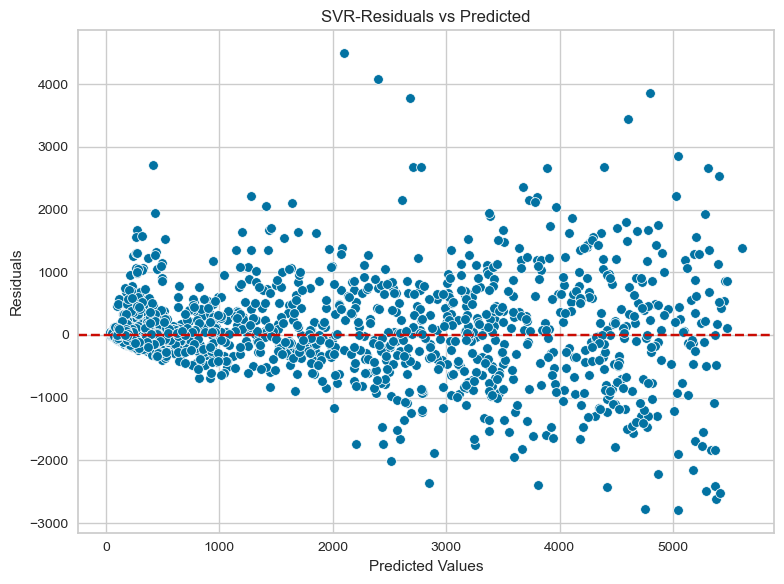

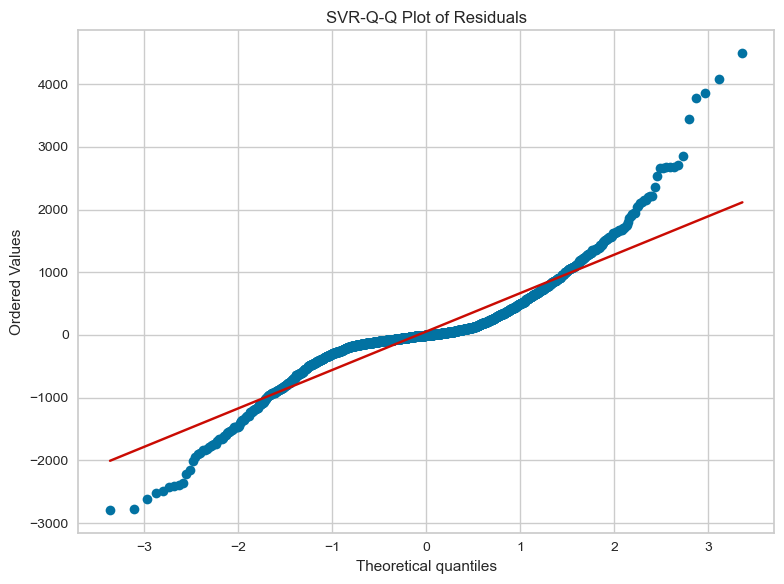

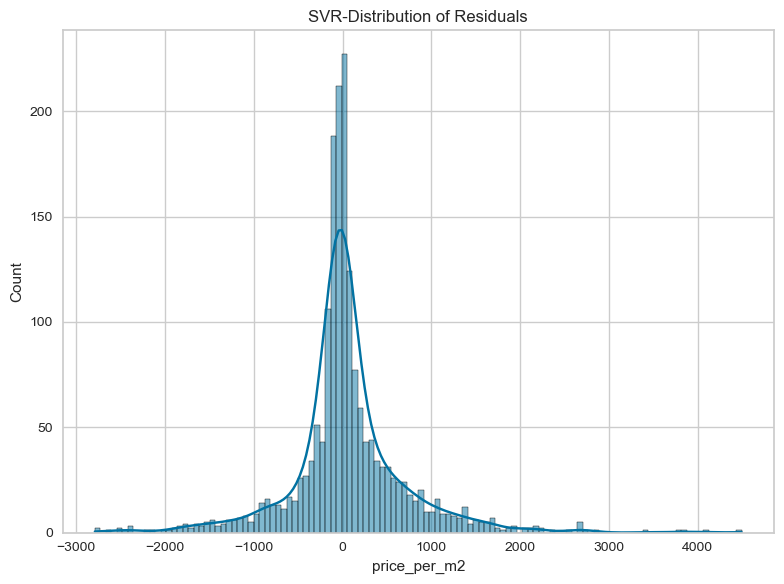

In [6]:
def plot_residuals_one_by_one(model, X_train, X_test, y_train, y_test):
    """Generate residual diagnostic plots, showing them one by one."""
    y_pred_test = model.predict(X_test)
    residuals = y_test - y_pred_test

    # Plot 1: Residuals vs Predicted
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=y_pred_test, y=residuals)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.title('SVR-Residuals vs Predicted')
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    plt.tight_layout()
    plt.show()

    # Plot 2: Q-Q Plot
    plt.figure(figsize=(8, 6))
    stats.probplot(residuals, plot=plt)
    plt.title('SVR-Q-Q Plot of Residuals')
    plt.tight_layout()
    plt.show()

    # Plot 3: Residual Distribution
    plt.figure(figsize=(8, 6))
    sns.histplot(residuals, kde=True)
    plt.title('SVR-Distribution of Residuals')
    plt.tight_layout()
    plt.show()

plot_residuals_one_by_one(model, X_train, X_test, y_train, y_test)

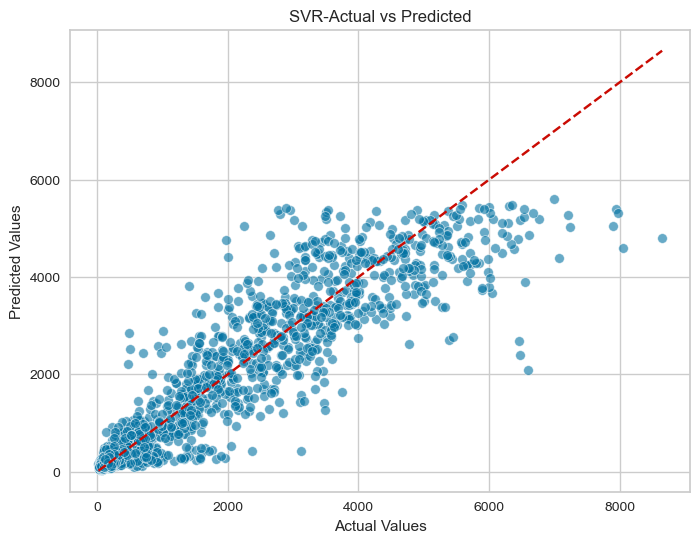

In [7]:
def plot_actual_vs_predicted(y_true, y_pred):
    """Scatter plot of actual vs predicted values"""
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.6)
    plt.plot([y_true.min(), y_true.max()], 
             [y_true.min(), y_true.max()], 'r--')
    plt.title('SVR-Actual vs Predicted')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.grid(True)
    plt.show()

y_pred_test = model.predict(X_test)
plot_actual_vs_predicted(y_test, y_pred_test)

In [8]:
# def plot_shap_summary(model, X, sample_size=100):
#     """Generate SHAP summary plot (using a sample for efficiency)"""
#     # For SVR, we need to use KernelExplainer
#     X_sample = X.sample(sample_size, random_state=42)
    
#     # Get the scaler and SVR from the pipeline
#     scaler = model.named_steps['standardscaler']
#     svr = model.named_steps['svr']
    
#     # Scale the sample
#     X_sample_scaled = scaler.transform(X_sample)
    
#     # Create explainer
#     explainer = shap.KernelExplainer(svr.predict, X_sample_scaled)
#     shap_values = explainer.shap_values(X_sample_scaled)
    
#     plt.figure()
#     shap.summary_plot(shap_values, X_sample, feature_names=X.columns, plot_type="bar")
#     plt.tight_layout()
#     plt.show()
    
#     plt.figure()
#     shap.summary_plot(shap_values, X_sample, feature_names=X.columns)
#     plt.tight_layout()
#     plt.show()
    
# plot_shap_summary(model, X_test)

d:\anaconda\envs\env_v3.10\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


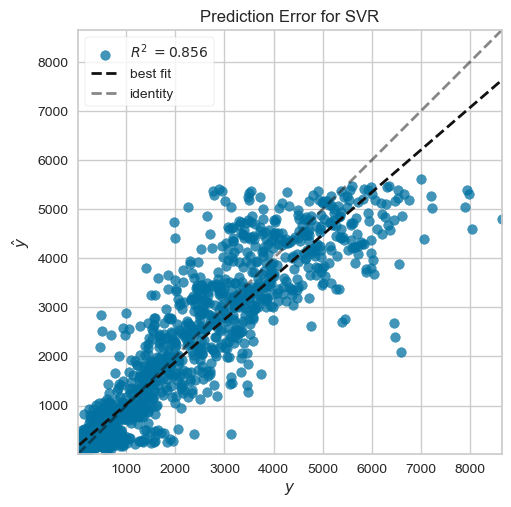

In [9]:

def plot_prediction_error(model, X_train, y_train, X_test, y_test):
    """Visualize prediction error with 45-degree line"""
    visualizer = prediction_error(
        model, X_train, y_train, X_test, y_test,
        bestfit=True, identity=True
    )
    visualizer.show()

plot_prediction_error(model, X_train, y_train, X_test, y_test)

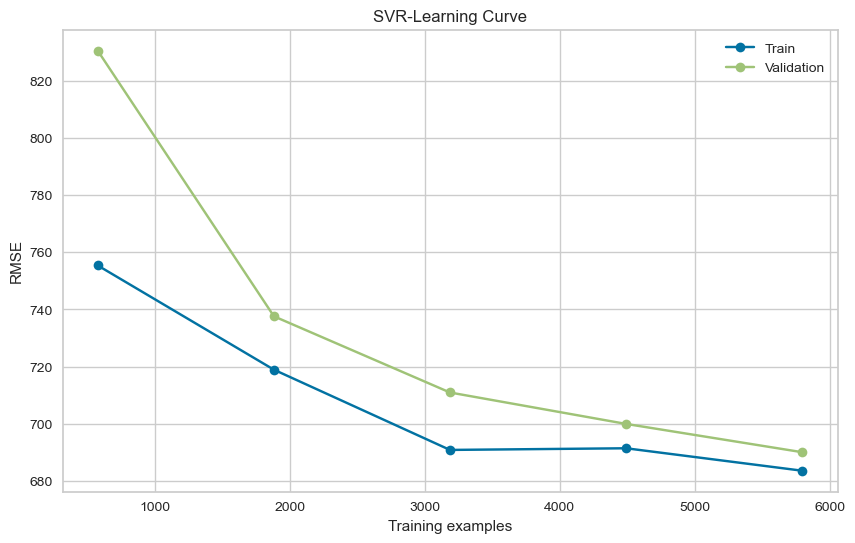

In [10]:
def plot_learning_curve(estimator, X, y):
    """Plot learning curve showing training and validation scores"""
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5),
        scoring='neg_root_mean_squared_error'
    )
    
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, -train_scores.mean(1), 'o-', label='Train')
    plt.plot(train_sizes, -test_scores.mean(1), 'o-', label='Validation')
    plt.xlabel('Training examples')
    plt.ylabel('RMSE')
    plt.title('SVR-Learning Curve')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_learning_curve(model, X_train, y_train)

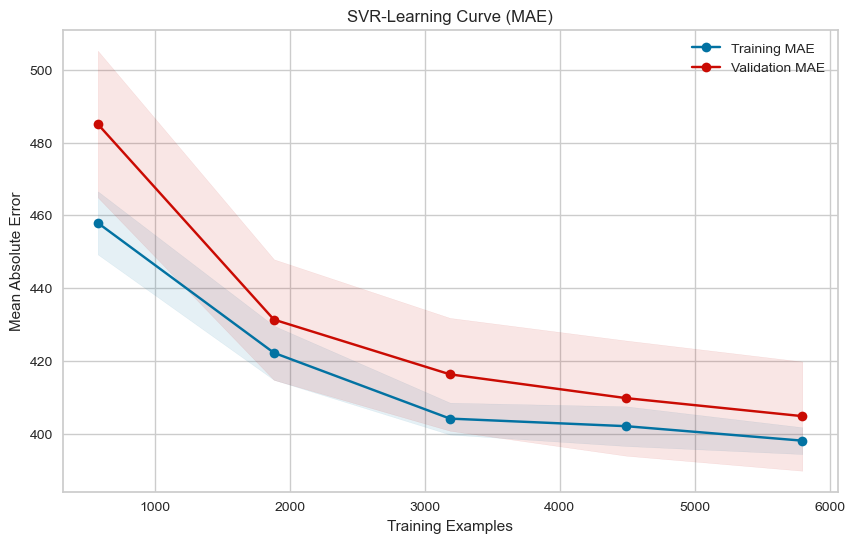

In [11]:
def plot_mae_learning_curve(estimator, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 5)):
    """Generate MAE-based learning curve"""
    train_sizes, train_scores, val_scores = learning_curve(
        estimator=estimator,
        X=X,
        y=y,
        cv=cv,
        n_jobs=-1,
        train_sizes=train_sizes,
        scoring='neg_mean_absolute_error'
    )
    
    train_mae = -train_scores
    val_mae = -val_scores
    
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mae.mean(axis=1), 'o-', color='b', label='Training MAE')
    plt.plot(train_sizes, val_mae.mean(axis=1), 'o-', color='r', label='Validation MAE')
    
    plt.title('SVR-Learning Curve (MAE)')
    plt.xlabel('Training Examples')
    plt.ylabel('Mean Absolute Error')
    plt.legend()
    plt.grid(True)
    
    plt.fill_between(train_sizes, 
                    train_mae.mean(axis=1) - train_mae.std(axis=1),
                    train_mae.mean(axis=1) + train_mae.std(axis=1),
                    alpha=0.1, color='b')
    
    plt.fill_between(train_sizes,
                    val_mae.mean(axis=1) - val_mae.std(axis=1),
                    val_mae.mean(axis=1) + val_mae.std(axis=1),
                    alpha=0.1, color='r')
    
    plt.show()

plot_mae_learning_curve(model, X_train, y_train)

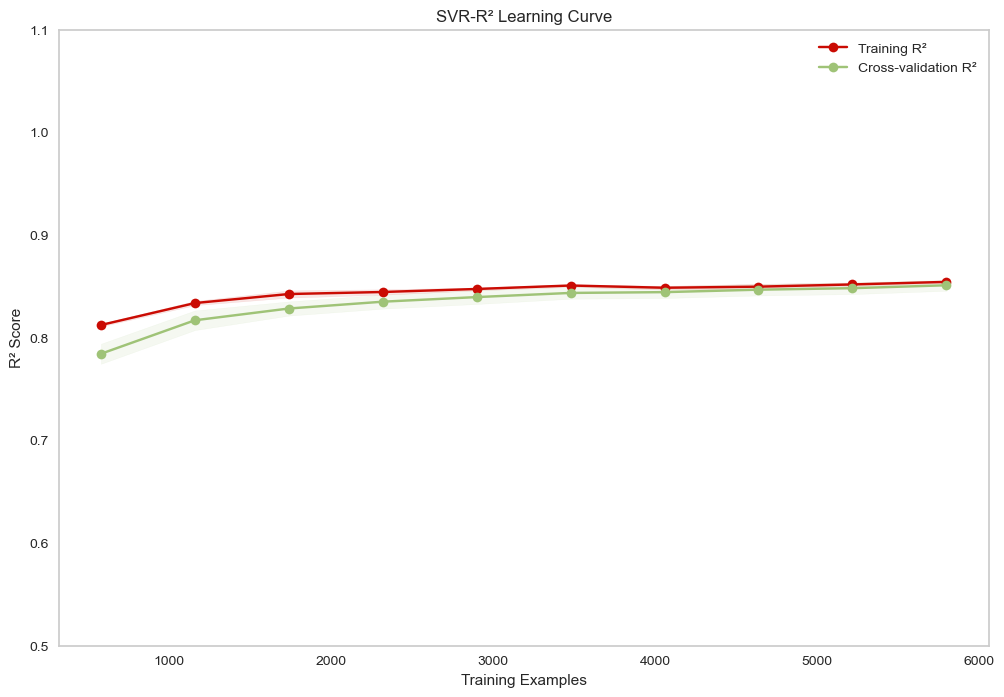

In [14]:
def plot_r2_learning_curve(estimator, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 10)):
    """Generate R² learning curve with confidence intervals"""
    train_sizes, train_scores, test_scores = learning_curve(
        estimator=estimator,
        X=X,
        y=y,
        cv=cv,
        n_jobs=-1,
        train_sizes=train_sizes,
        scoring='r2'
    )
    
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    plt.figure(figsize=(12, 8))
    plt.title("SVR-R² Learning Curve")
    plt.xlabel("Training Examples")
    plt.ylabel("R² Score")
    plt.ylim(0.5, 1.1)
    
    plt.fill_between(train_sizes, 
                    train_scores_mean - train_scores_std,
                    train_scores_mean + train_scores_std,
                    alpha=0.1, color="r")
    plt.fill_between(train_sizes, 
                    test_scores_mean - test_scores_std,
                    test_scores_mean + test_scores_std,
                    alpha=0.1, color="g")
    
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training R²")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation R²")
    
    plt.legend(loc="best")
    plt.grid()
    plt.show()

plot_r2_learning_curve(model, X_train, y_train)